# Week 7: Text Data & PDF Parsing

This notebook has **two parts**:

1. **Part 1 – Counting Words in Manifesto Data**: Learn how to load text datasets, perform tokenization, and compute word frequencies.
2. **Part 2 – Reading PDF Data (IMF Reports)**: Extract raw text from PDF files and analyze word counts using machine learning tools.

* * *

## Why does text representation matter?

Text data is unstructured, and to analyze it quantitatively, we represent it numerically. The simplest representation is the **Bag-of-Words** model, where we count how many times each word appears in each document.

| Step | What it does | Example |
|------|--------------|---------|
| **Tokenization** | Split text into individual words | 'Reading PDF Data' &rarr; ['Reading', 'PDF', 'Data'] |
| **Stop Words Removal** | Remove extremely common words with little meaning | 'in', 'the', 'is', 'and' are ignored |
| **N-grams** | Group consecutive sequences of N words | Bigrams ('social security'), Trigrams ('elected coalition government') |

Both single words and n-grams help capture themes, policy focus, and sentiment in public policy documents.

# Part 1: Counting Words in Manifesto Data

## 1.1 Counting words

In [1]:
import pandas as pd
# IF previous 2.A doesn't work
file_name = "../../data/examples/week_7/manifesto_english_speaking.parquet"
df_all = pd.read_parquet(file_name)
df_all.reset_index().countryname.unique().tolist()

['Australia',
 'Canada',
 'Ireland',
 'South Africa',
 'United Kingdom',
 'United States']

### 1.1.1 Create count function

In [2]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{6,}\b")
count_array = vectorizer.fit_transform(df_all['text']).toarray()

### 1.1.2 Make the count function into a dataframe

In [3]:
df_wordcount = pd.DataFrame(
    count_array, # Data above will become the values of the dataframe
    columns=vectorizer.get_feature_names_out(), # Words will become the column names
    index = df_all.index # Index country date comes from the df_all dataframe
)
df_wordcount.head(2)

aamericans  aandes  aanounced  aarhus  abaissant  \
countryname date                                                           
Australia   1961-12-01           0       0          0       0          0   
            1961-12-01           0       0          0       0          0   

                        abaisse  abaisser  abalone  abandon  abandoned  ...  \
countryname date                                                        ...   
Australia   1961-12-01        0         0        0        0          0  ...   
            1961-12-01        0         0        0        0          0  ...   

                        zolgensma  zombie  zonage  zoning  zonings  zooming  \
countryname date                                                              
Australia   1961-12-01          0       0       0       0        0        0   
            1961-12-01          0       0       0       0        0        0   

                        zoonoses  zululand  zurich  zwelisha  
countryname date                                              
Australia   1961-12-01         0         0       0         0  
            1961-12-01         0         0       0         0  

[2 rows x 39843 columns]

### 1.1.3 Show most common words

In [4]:
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10)

,most_common
government,32119
people,17950
support,16724
million,13540
national,13433
health,13164
public,12099
ensure,12068
services,11492
australia,11441


## 1.2 Count n-grams (more than one word combinations)

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
# Now we can get fancier with the count vectorizer by counting more than one word combinations and remove stop words
vectorizer = CountVectorizer(
    analyzer = 'word',          # Whether the feature should be made of word or character n-grams or a mixture of both.
    stop_words = 'english',     # Remove stop words. Can be a list of stop words or a string from {'english', 'spanish'}.
    lowercase = True,           # Convert text to lowercase.
    ngram_range = (3,3),
    
)
# Count!
count_array = vectorizer.fit_transform(df_all['text']).toarray()
df_wordcount = pd.DataFrame(
    count_array, # Data above will become the values of the dataframe
    columns=vectorizer.get_feature_names_out(), # Words will become the column names
    index = df_all.index # Index country date comes from the df_all dataframe
)
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10)

,most_common
le bloc québécois,2140
elected coalition government,1164
le gouvernement fédéral,949
shorten labor government,674
que le gouvernement,424
liberal nationals government,405
aboriginal torres strait,339
elected morrison government,338
coalition government continue,329
du gouvernement fédéral,327


<Axes: >

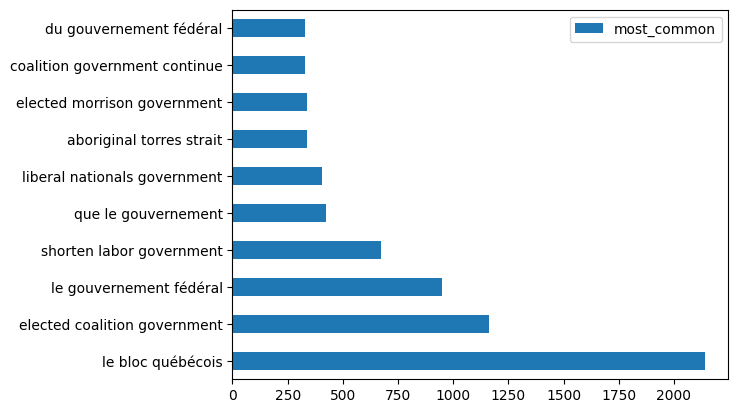

In [6]:
df_wordcount.sum(axis='rows').sort_values(ascending=False).to_frame("most_common").head(10).plot(kind = 'barh')

## 1.3 Visualizing word count in dataframe

In [7]:
vectorizer = CountVectorizer(
    analyzer = 'word',          # Whether the feature should be made of word or character n-grams or a mixture of both.
    stop_words = 'english',     # Remove stop words. Can be a list of stop words or a string from {'english', 'spanish'}.
    lowercase = True,           # Convert text to lowercase.
    ngram_range = (1,3),
    min_df = .1
    
)
counts = vectorizer.fit_transform(df_all['text']).toarray().sum(axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), counts))

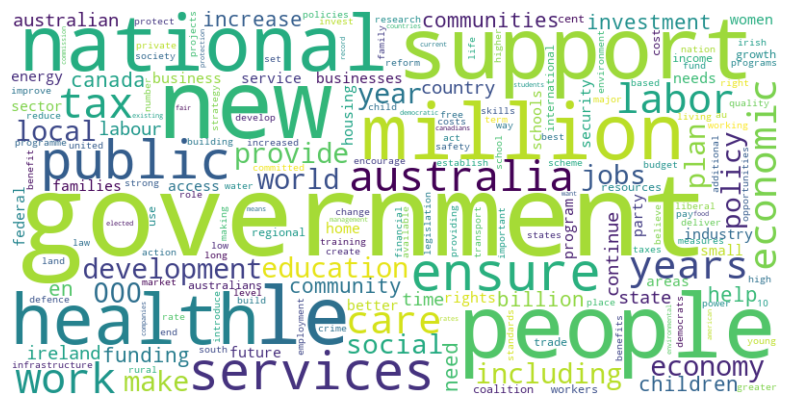

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(word_freq)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

## 1.4 Make into a function

In [9]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_country_wordcloud(country_name, df, ax=None, save_path=None):
    country_df = df.query(f"countryname == '{country_name}'")
    vectorizer = CountVectorizer(
        analyzer='word',
        stop_words='english',
        lowercase=True,
        ngram_range=(1, 3),
        min_df=0.1
    )

    counts = vectorizer.fit_transform(country_df['text']).toarray().sum(axis=0)
    word_freq = dict(zip(vectorizer.get_feature_names_out(), counts))

    wordcloud = WordCloud(width=800, height=400, background_color='white')
    wordcloud.generate_from_frequencies(word_freq)

    if ax:
        ax.imshow(wordcloud)
        ax.axis('off')
        ax.set_title(f"Word Cloud for {country_name}", size=20)
    else:
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.title(f"Word Cloud for {country_name}", size=20)

    if save_path:
        plt.savefig(save_path)

### 1.4.1 One example

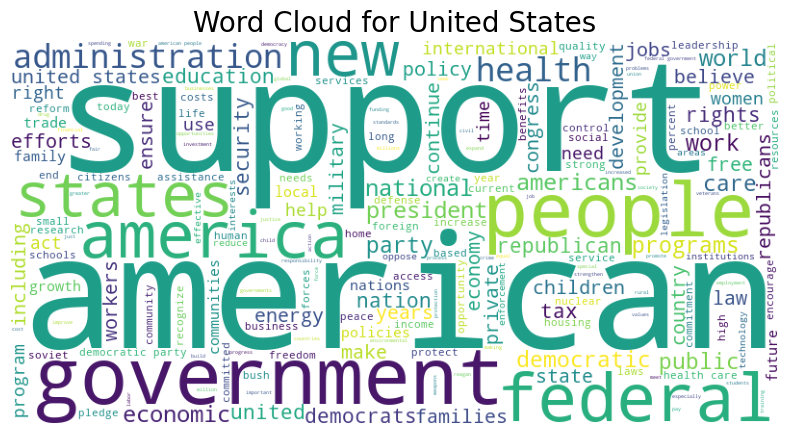

In [10]:
#fig, axes = plt.subplots(figsize=(12, 10))

generate_country_wordcloud(
    country_name = 'United States',
    df = df_all,
    #ax = axes
)

### 1.4.2 Multiple

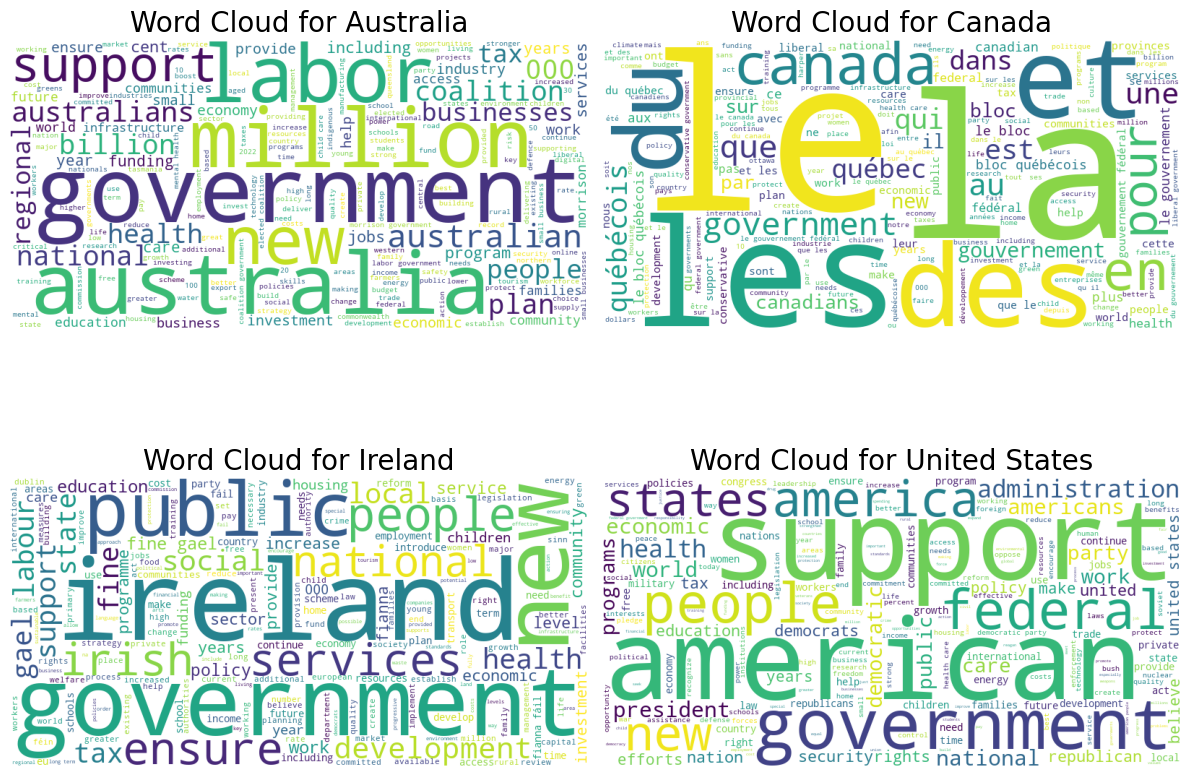

In [11]:
countries_to_plot = ['Australia', 'Canada', 'Ireland', 'United States'] # A sample of 4 countries for a 2x2 grid

# 3. Create a 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes to easily iterate through them
for i, country in enumerate(countries_to_plot):
    generate_country_wordcloud(
        country, df_all, axes[i] # Run function for all
                              )
plt.tight_layout()


## 1.5 Count words across time

### 1.5.1 Count by country

In [12]:
vocab_list = ['environment', 'emissions']
vectorizer = CountVectorizer(
    stop_words = 'english',     # Remove stop words. Can be a list of stop words or a string from {'english', 'spanish'}.
    lowercase = True,           # Convert text to lowercase.
    ngram_range = (1,1),
    vocabulary = vocab_list 
    
)
counts = vectorizer.fit_transform(df_all['text']).toarray().sum(axis=0)
word_freq = dict(zip(vectorizer.get_feature_names_out(), counts))
word_freq

{'environment': np.int64(3250), 'emissions': np.int64(1485)}

### 1.5.2 Count by year and date

In [13]:
# add year column
df_all = df_all.reset_index().assign(year = lambda column: column['date'].dt.year)
df_all.head(2)

,countryname,date,party,partyname,keys,manifesto_id,text,year
0,Australia,1961-12-01,63320,Australian Labor Party,63320_196112,63320_196112,Labour government would subsidise interest rat...,1961
1,Australia,1961-12-01,63330,Democratic Labor Party,63330_196112,63330_196112,New concepts needed for Nation’s problems. Me...,1961


In [14]:
word_freq_by_country = {}
for country_name, country_df in df_all.groupby(['countryname', 'year']):
    vectorizer = CountVectorizer(
        stop_words='english',
        lowercase=True,
        ngram_range=(1, 1),
        vocabulary=vocab_list
    )
    counts = vectorizer.fit_transform(country_df['text']).toarray().sum(axis=0)
    word_freq_by_country[country_name] = dict(zip(vectorizer.get_feature_names_out(), counts))
df_timeseries = pd.DataFrame(word_freq_by_country).transpose()
df_timeseries.head(2)

environment  emissions
Australia 1961            0          0
          1963            0          0

#### Convert to Long

In [15]:
df_long = df_timeseries.stack().to_frame('count').reset_index()
df_long.head(3)

,level_0,level_1,level_2,count
0,Australia,1961,environment,0
1,Australia,1961,emissions,0
2,Australia,1963,environment,0


In [16]:
df_long = df_long.rename({"level_0": 'country', 'level_1':'year', 'level_2': 'vocab'}, axis='columns')
df_long.head(2)

,country,year,vocab,count
0,Australia,1961,environment,0
1,Australia,1961,emissions,0


#### Plot

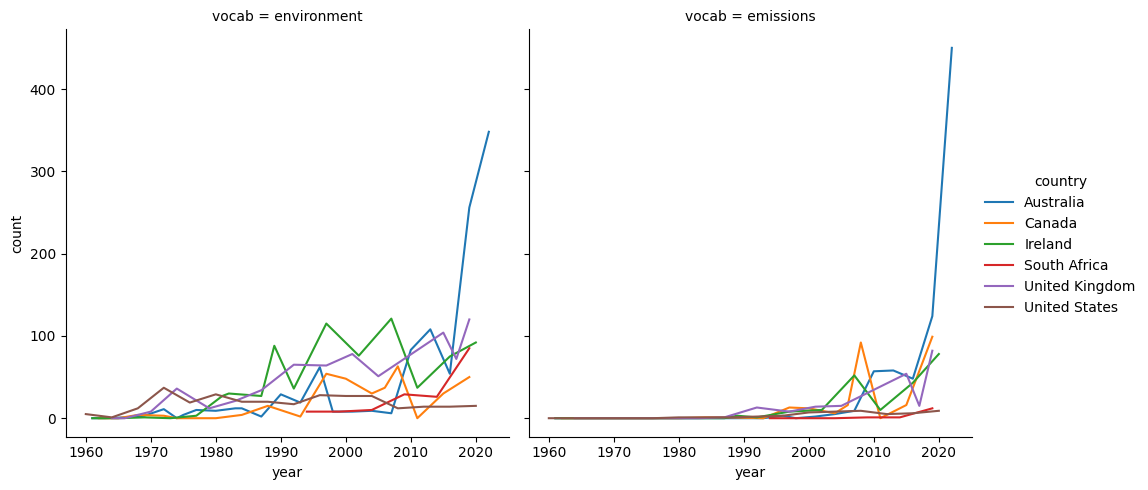

In [17]:
import seaborn as sns
sns.relplot(
    data=df_long, x="year", y="count", hue="country", col="vocab", kind="line"
)

# Part 2: Reading PDF Data (IMF Reports)

In this section, we show how to read PDF files from the `data/examples/week_7/imf_reports` directory and extract their text using the `pypdf` library. We then construct a Pandas DataFrame and count specific words to analyze the reports.

In [18]:
import os
from pypdf import PdfReader
import pandas as pd
from pathlib import Path

# Construct path relative to project root
pdf_dir = "../../data/examples/week_7/imf_reports"
os.listdir(pdf_dir)


['Angola_2026.pdf', 'Antigua_2026.pdf']

In [19]:
reader = PdfReader("../../data/examples/week_7/imf_reports/" + "Angola_2026.pdf")
full_text = ""
for page in reader.pages:
    full_text += page.extract_text()

print(full_text[:500])

 
© 2026 International Monetary Fund 
IMF Country Report No. 26/94 
ANGOLA 
2026 ARTICLE IV CONSULTATION—PRESS RELEASE; 
STAFF REPORT; INFORMATIONAL ANNEX AND 
STATEMENT BY THE EXECUTIVE DIRECTOR FOR 
ANGOLA 
Under Article IV of the IMF’s Articles of Agreement, the IMF holds bilateral discussions 
with members, usually every year. In the context of the 2026 Article IV consultation with 
Angola, the following documents have been released and are included in this package: 
 
• A Press Release summ


## 2.1 Counting words in the IMF Reports

Now, we count words in the extracted text using the `CountVectorizer` from `scikit-learn`, just like the manifesto word count example below.

In [20]:
# 1. Set directory and list files
pdf_dir = "../../data/examples/week_7/imf_reports"
pdf_files = [f for f in os.listdir(pdf_dir) if f.endswith(".pdf")]

# 2. Extract text from each PDF
data = []
for pdf_file in pdf_files:
    path = os.path.join(pdf_dir, pdf_file)
    reader = PdfReader(path)
    
    # Combine text from all pages
    text = "\n".join([page.extract_text() or "" for page in reader.pages])
    
    # Use filename (minus .pdf) as country name
    country = pdf_file.replace(".pdf", "")
    data.append({"country": country, "text": text})

df_imf = pd.DataFrame(data)
df_imf.head(2)

,country,text
0,Angola_2026,\n© 2026 International Monetary Fund \nIMF Co...
1,Antigua_2026,\n© 2026 International Monetary Fund \nIMF Co...


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Count words of length 6 or more
vectorizer = CountVectorizer(token_pattern=r"(?u)\b[a-zA-Z]{6,}\b")
count_array = vectorizer.fit_transform(df_imf["text"]).toarray()

# Convert to DataFrame
df_wordcount_imf = pd.DataFrame(
    count_array,
    columns=vectorizer.get_feature_names_out(),
    index=df_imf["country"]
)

# Display the 10 most common words across the reports
df_wordcount_imf.sum(axis="rows").sort_values(ascending=False).to_frame("most_common").head(10)

,most_common
percent,434
fiscal,291
financial,288
international,256
authorities,238
angola,225
monetary,222
antigua,218
barbuda,218
external,216
